# Simulation

In [1]:
import pytweezer.phasemask as pm
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

In [3]:
PM = pm.OptimisationBasedPhasemaskGeneratorGPU(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40.0, 0.0))

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (40.0, 0.0) um


--- Target Generation ---
Grid: 1x1
Spacing: 1 um
--- Starting GPU Superposition Phase Retrieval ---
Iteration 499 | Mean-Squared Error: 0.00e+00 | Uniformity: 100.00% | Min/Max ratio: 1.000
Optimization finished in 0.37 seconds.


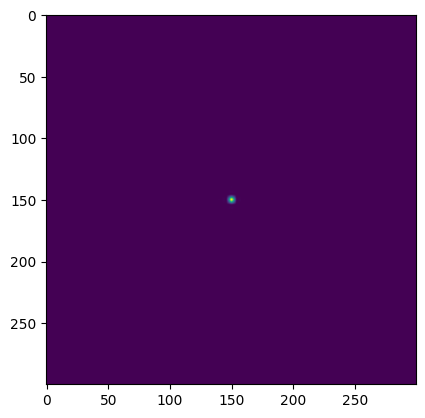

In [4]:
W = np.ones((1, 1))
spacing_um = 1
target = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
pm, terms, _ = PM.superposition_optimization(target, max_iter=500, damping=0.5, verbose=False)
X_slm, Y_slm = cp.meshgrid(PM.x_slm, PM.y_slm)
dz = 0
phi_defoc = - np.pi / (PM.lam) * (dz / (PM.f_um * (PM.f_um + dz))) * (X_slm**2 + Y_slm**2)
pm_final = PM.superimpose([pm, phi_defoc])
out = np.abs(PM.simulate_focal_plane(pm_final, Nx_pad=2096*2, Ny_pad=2096*2, show=False, zoom_pixels=20, cmap='viridis'))**2
h,w = out.shape
window = 150
out_cropped = out[h//2-window:h//2+window, w//2-window:w//2+window]
plt.imshow(out_cropped, cmap='viridis')

In [5]:
dz_list = np.linspace(-50, 50, 80)

phi_zernike = PM.generate_zernike_phasemask({5: 1.5, 6: -1.5, 7:-0.05, 8: 0.1, 9: 0.05, 10: -0.02, 11: 0.01})

intensity = []
for dz in dz_list:
    phi_defoc = - np.pi / (PM.lam) * (dz / (PM.f_um * (PM.f_um + dz))) * (X_slm**2 + Y_slm**2)
    pm_final = PM.superimpose([-pm, phi_defoc, phi_zernike])
    out = np.abs(PM.simulate_focal_plane(pm_final, Nx_pad=2096*2, Ny_pad=2096*2, show=False, zoom_pixels=20, cmap='viridis'))**2
    h,w = out.shape
    window = 150
    out_cropped = out[h//2-window:h//2+window, w//2-window:w//2+window]
    intensity.append(out_cropped)

intensity = np.array(intensity)

Text(0, 0.5, 'z (um)')

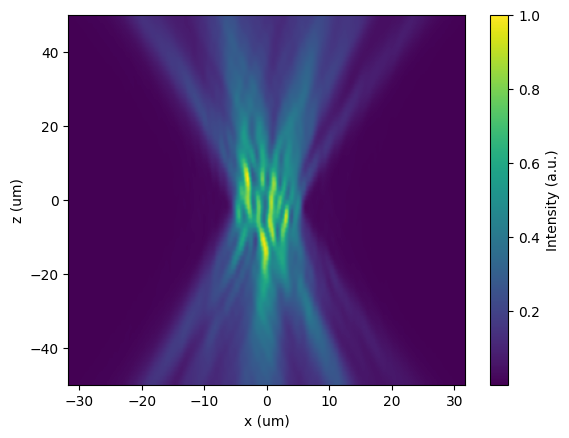

In [54]:
h,w = intensity[0].shape
intensity = intensity[:, :].sum(axis=2)
intensity /= intensity.max()

plt.imshow(intensity, extent=[-w/2 * PM.dx_f/4, w/2 * PM.dx_f/4, dz_list[0], dz_list[-1]], aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity (a.u.)')
plt.xlabel("x (um)")
plt.ylabel("z (um)")

Text(0, 0.5, 'z (um)')

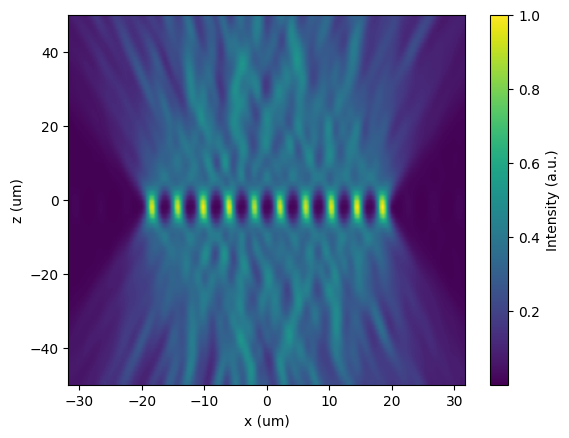

In [6]:
h,w = intensity[0].shape
intensity = intensity[:, :].sum(axis=2)
intensity /= intensity.max()

plt.imshow(intensity, extent=[-w/2 * PM.dx_f/4, w/2 * PM.dx_f/4, dz_list[0], dz_list[-1]], aspect='auto', cmap='viridis')
plt.colorbar(label='Intensity (a.u.)')
plt.xlabel("x (um)")
plt.ylabel("z (um)")

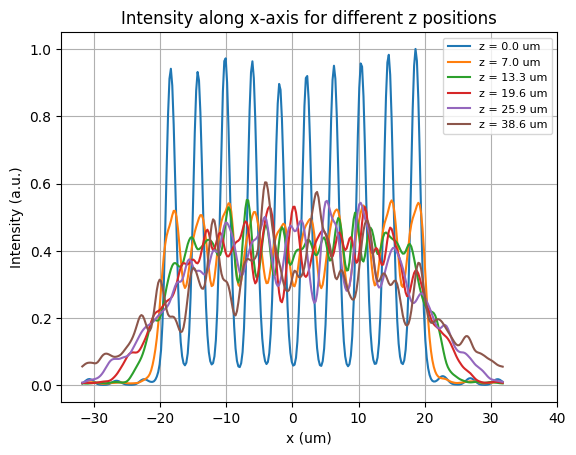

In [46]:
I1D00 = (intensity[39, :] + intensity[40, :]) / 2
I1D0 = I1D00 / I1D00.max()
I1D1 = intensity[45, :] / I1D00.max()
I1D2 = intensity[50, :] / I1D00.max()
I1D3 = intensity[55, :] / I1D00.max()
I1D4 = intensity[60, :] / I1D00.max()
I1D5 = intensity[70, :] / I1D00.max()

x = np.linspace(-w/2 * PM.dx_f/4, w/2 * PM.dx_f/4, I1D0.shape[0])

plt.plot(x, I1D0, label=f"z = {0.0} um",  color='C0')
plt.plot(x, I1D1, label=f"z = {dz_list[45]:.1f} um",  color='C1')
plt.plot(x, I1D2, label=f"z = {dz_list[50]:.1f} um",  color='C2')
plt.plot(x, I1D3, label=f"z = {dz_list[55]:.1f} um",  color='C3')
plt.plot(x, I1D4, label=f"z = {dz_list[60]:.1f} um",  color='C4')
plt.plot(x, I1D5, label=f"z = {dz_list[70]:.1f} um",  color='C5')
plt.legend(fontsize=8)
plt.xlim(None, 40)
plt.xlabel("x (um)")
plt.ylabel("Intensity (a.u.)")
plt.title("Intensity along x-axis for different z positions")
plt.grid()

In [1]:
import pytweezer.phasemask as pm
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp

--- System Configuration ---
SLM Plane Width: 17.41 mm
SLM Plane Height: 17.41 mm
Focal Plane Resolution x (pixel size): 0.8467 um
Focal Plane Resolution y (pixel size): 0.8467 um
Focal Plane Width: 867.04 um
Focal Plane Height: 867.04 um
Fresnel Lens Focal Length: 1072.00 mm
Blazed Grating Displacement (dx, dy): (40.0, 0.0) um
--- Target Generation ---
Grid: 10x10
Spacing: 4 um
--- Starting GPU Superposition Phase Retrieval (3D) ---
Iteration 000 | Mean-Squared Error: 3.96e-06 | Uniformity: 80.10% | Min/Max ratio: 0.352
Iteration 010 | Mean-Squared Error: 2.59e-08 | Uniformity: 98.39% | Min/Max ratio: 0.921
Iteration 020 | Mean-Squared Error: 6.68e-09 | Uniformity: 99.18% | Min/Max ratio: 0.952
Iteration 030 | Mean-Squared Error: 2.56e-09 | Uniformity: 99.49% | Min/Max ratio: 0.976
Iteration 040 | Mean-Squared Error: 3.86e-09 | Uniformity: 99.38% | Min/Max ratio: 0.974
Iteration 050 | Mean-Squared Error: 3.28e-09 | Uniformity: 99.43% | Min/Max ratio: 0.966
Iteration 060 | Mean-Squared

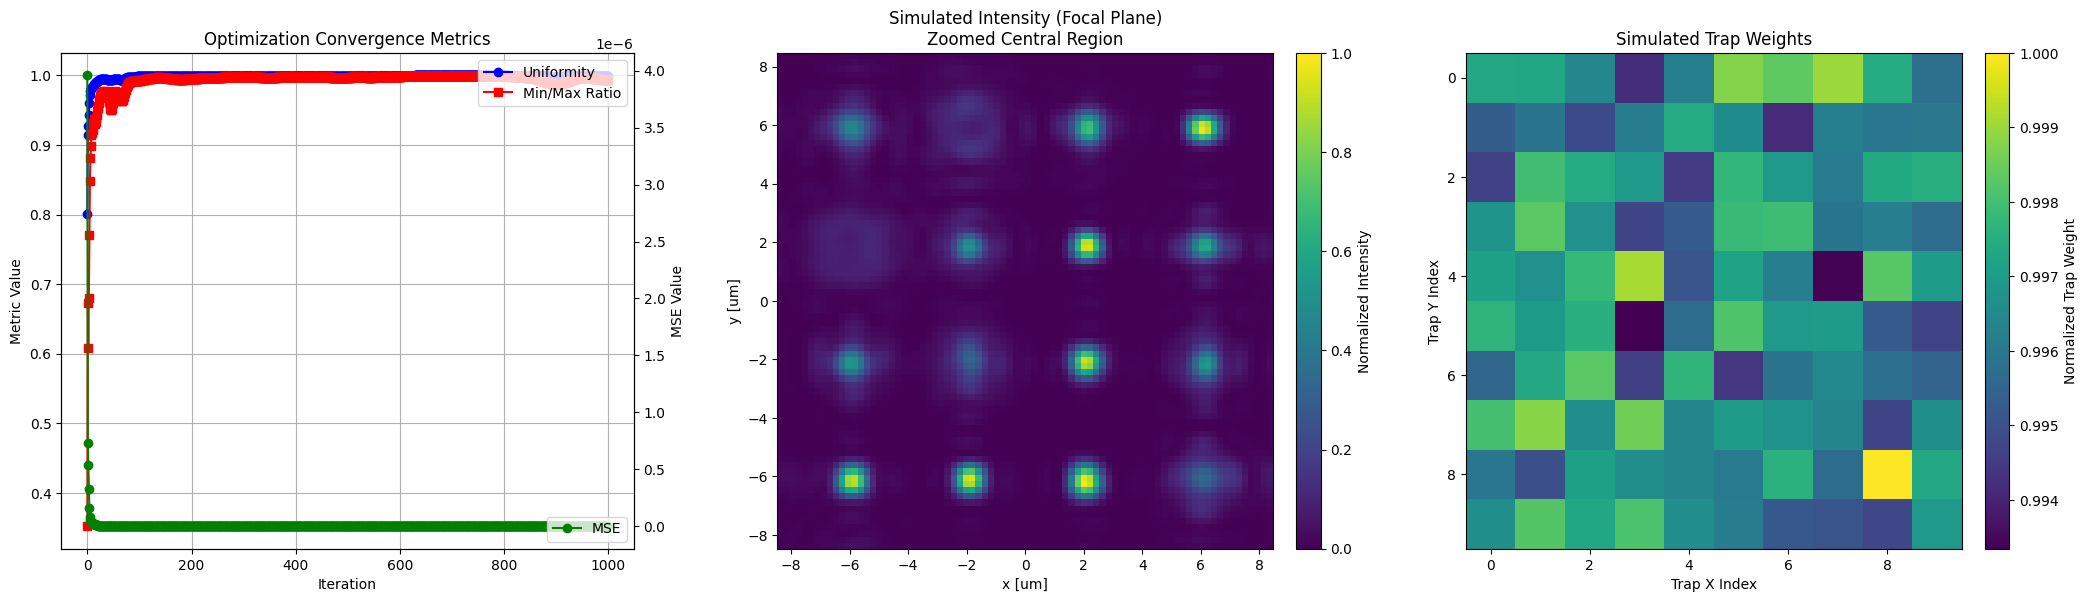

In [10]:
PM = pm.OptimisationBasedPhasemaskGeneratorGPU3D(
                 wavelength_um=0.852,
                 focal_length_mm=17.3,
                 slm_pitch_um=17,
                 slm_res=(1024,1024),
                 input_beam_waist_mm=16,
                 fresnel_f_mm=1072,
                 blaze_dx_dy_um=(40.0, 0.0))

W = np.ones((10, 10))
spacing_um = 4

target = PM.generate_weighted_array(W, spacing_um, init_phase_randomness=1.0)
w_n, theta_n, x_n, y_n, z_n, array_shape = target
z_n = np.random.uniform(-5, 5, size=z_n.shape)
target = (w_n, theta_n, x_n, y_n, z_n, array_shape)

pm_array, terms, metrics = PM.superposition_optimization(target, max_iter=1000, damping=0.5, verbose=True)

PM.visualise_algorithm_performance(pm_array, metrics, 10, pad=4)